<h1>Feature Scaling</h1>
<p>A data preprocessing technique used in machine learning to normalize or standardize the range of independent variables (features)</p>

<p>Since features in a dataset may have very different units and scales (e.g., age in years vs. income in dollars), models that rely on distance calculations can be biased toward features with larger numeric ranges. Features scaling ensures that all features contribute proportionally to the model</p>

<h2>Why Feature Scaling Matters</h2>
<ul>
    <li><b>Improve model performance:</b> algorithms like gradient descent converge faster when features are normalized, since they don't have to "zig-zag" across uneven scales</li>
    <li><b>Interpretabililty:</b> standardized features (mean 0, variance 1) make it easier to compare the relative importance of coefficients in linear models</li>
    <li><b>Better Accuracy:</b> distance-based models such as KNN, K-means, and SVMs perform more reliably with scaled features</li>
    <li><b>Faster Convergence:</b> neural networks and gradient descent optimizers reach optimal solutions more quickly when features are scaled</li>
</ul>

<h2>Common Feature Scaling Techniques</h2>

<h3>Standardization</h3>
<p>A widely used scaling technique (also known as Z-score Normalization) that transforms features so that they have a mean of 0 and a standard deviation of 1. Unlike min-max scaling, it does not bound values within a fixed range; instead, it creates features and scales them to unit variance</p>
<p>Standardization does not change the underlying shape or distribution of your data. If your data was heavily skewed to the left before, it will still be skewed to the left after - it will just be skewed around the number zero</p>

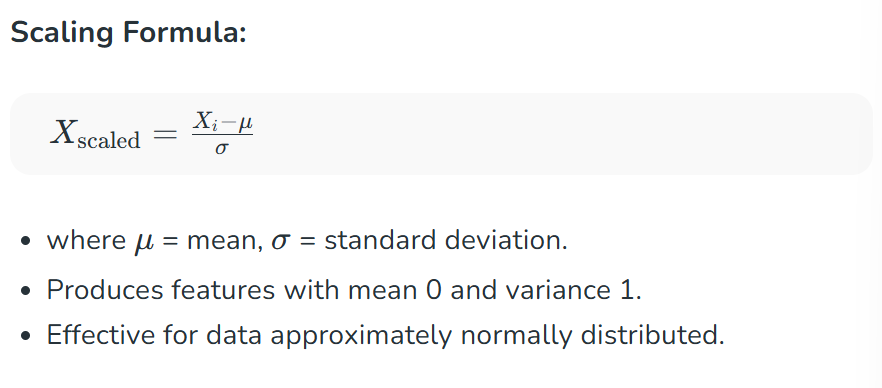

<h2>When Should You Use Standardizaton</h2>
<p>Not all models need scaled data, but many absolute rely on it</p>
<ul>
    <li><b>Models that compute distance:</b> algorithms like K-Nearest Neighbors, Support Vector Machines, and K-Means Clustering calculate the physical distance between data points. If you do not scale, the feature with the largesst numbers will completely dominate the distance calculation</li>
    <li><b>Models the use Gradient Descent:</b> algorithms like Linear Regression, Logistic Regression, and Neural Networks learn by taking steps toward a solution. If features are on widely different scales, the model will take a very zig-zagged, slow, and unstable path to the right answer. Standardization helps the learn much faster</li>
    <li><b>When NOT to worry about it:</b> tree-based models (like Decision Treees, Random Forest, and XGBoost) make decisions by splitting data at specific values (e.g., "is house size > 2000?"). They do not care about the scale at all, so standardization is not strictly necessary for them</li>
</ul>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Standardization From Scratch</h3>

In [2]:
class ManualStandardScaler:
    def __init__(self):
        # we initialize our mean and standard deviation as None
        self.mu = None
        self.sigma = None
    def fit(self, X):
        # axis = 0 means we calculate the mean and standard deviation for each feature (column) independently
        self.mu = np.mean(X, axis = 0)
        self.sigma = np.std(X, axis = 0)

        # print(self.mu)
        # print(self.sigma)

        # returning 'self' is a standard convention in ML libraries
        return self

    def transform(self, X):
        # a safety check to ensure the user called fit() first
        if self.mu is None or self.sigma is None:
            raise ValueError("You must fit the scaler before transforming data")

        # apply the Z-score formula: (x - mean)/standard deviation
        return (X - self.mu)/self.sigma

    def fit_transform(self, X):
        # a convenience method to do both steps at once
        self.fit(X)
        return self.transform(X)
        

# Dummy Data: [House Size, Bedrooms]
X_train = np.array([
    [1500, 3],
    [2500, 4],
    [1000, 2],
    [3000, 5]
])

# initialize the manual scaler (object creation)
scaler = ManualStandardScaler()

# fit and transform the data (call the function)
scaled_X = scaler.fit_transform(X_train)

print("--- Manual Scaler Results ---")
print("Calculated Means:", scaler.mu)
print("Calculated Std Devs:", scaler.sigma)
print("\nStandardized Data:\n", np.round(scaled_X, 3))

pd.DataFrame(scaled_X, columns = ['House Size', 'Bedrooms'])

--- Manual Scaler Results ---
Calculated Means: [2000.     3.5]
Calculated Std Devs: [790.56941504   1.11803399]

Standardized Data:
 [[-0.632 -0.447]
 [ 0.632  0.447]
 [-1.265 -1.342]
 [ 1.265  1.342]]


,House Size,Bedrooms
0,-0.632456,-0.447214
1,0.632456,0.447214
2,-1.264911,-1.341641
3,1.264911,1.341641


<h3>Standardization Using the Industry Module</h3>

In [3]:
from sklearn.preprocessing import StandardScaler

# initialize the sklearn scaler
scaler = StandardScaler()

# fit and transform the data
X_scaled = scaler.fit_transform(X_train)

print("--- Scikit-Learn Results ---")
print("Calculated Means:", scaler.mean_)
print("Calculated Std Devs:", scaler.scale_)
print("\nStandardized Data:\n", np.round(X_scaled, 3))

--- Scikit-Learn Results ---
Calculated Means: [2000.     3.5]
Calculated Std Devs: [790.56941504   1.11803399]

Standardized Data:
 [[-0.632 -0.447]
 [ 0.632  0.447]
 [-1.265 -1.342]
 [ 1.265  1.342]]


<h3>Apply on a real dataset</h3>

In [4]:
df = pd.read_csv('Social_Network_Ads.csv')

df.sample(5)

,User ID,Gender,Age,EstimatedSalary,Purchased
55,15649136,Female,24,55000,0
117,15591433,Male,36,52000,0
148,15779862,Male,29,61000,0
396,15706071,Male,51,23000,1
219,15732987,Male,59,143000,1


In [5]:
# extract only the numerical features we want to scale
# we convert it to a NumPy arary because our manual class expects arrays
X_real = df[['Age', 'EstimatedSalary']].values

class CustomStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis = 0)
        self.scale_ = np.std(X, axis = 0)

        return self

    def transform(self, X):
        if self.mean_ is None or self.scale_ is None:
            raise ValueError("You must fit the scaler before transform")
        return (X - self.mean_)/self.scale_

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

scaler = CustomStandardScaler()

X_real_scaled = scaler.fit_transform(X_real)

df_scaled = pd.DataFrame(X_real_scaled, columns = ['Age Scaled', 'Salary Scaled'])
df_scaled.head()

,Age Scaled,Salary Scaled
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


In [6]:
X_real_df = df[['Age', 'EstimatedSalary']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_real_df)
X_scaled_df = pd.DataFrame(X_scaled, columns = ['age_scaled', 'salary_scaled'])
X_scaled_df.head()

,age_scaled,salary_scaled
0,-1.781797,-1.490046
1,-0.253587,-1.460681
2,-1.113206,-0.785290
3,-1.017692,-0.374182
4,-1.781797,0.183751


<h3>Why do we need scaling</h3>

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [8]:
# load the dataset and split features (X) and target (y)
df = pd.read_csv('Social_Network_Ads.csv')

X = df[['Age','EstimatedSalary']]
y = df['Purchased']

# split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

# KNN on unscaled data
model_unscaled = KNeighborsClassifier(n_neighbors = 5)
model_unscaled.fit(X_train, y_train)
y_predict_unscaled = model_unscaled.predict(X_test)

print(f"Unscaled Accuracy:{accuracy_score(y_test, y_predict_unscaled)*100:.2f}%")


# KNN on scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = KNeighborsClassifier(n_neighbors = 5)
model_scaled.fit(X_train_scaled, y_train)
y_predict_scaled = model_scaled.predict(X_test_scaled)

print(f"Scaled Accuracy: {accuracy_score(y_test, y_predict_scaled)*100:.2f}%")


Unscaled Accuracy:82.00%
Scaled Accuracy: 93.00%


<h3>Normalization</h3>

<h4>Min-Max Scaling</h4>
<p>While Standardization reshapes your data to have a mean of 0 and a standard deviation of 1, Normalization takes a very different approach. Normalization is the other main type of feature scaling, and is widely known in industry as <b>Min-Max scaling</b></p>

<p>Instead of centering data around zero, <b>Min-Max scaling</b> acts like a strict container. It literally squashes or stretches your data so that every single data point fits precisely within a fixed, predefiened range -- <b>almost always between 0 and 1</b></p>

<h3>Formula</h3>
<p>The math behind this is very intuitive. To normalize a feature, you apply the following formula to every single value in your dataset:</p>

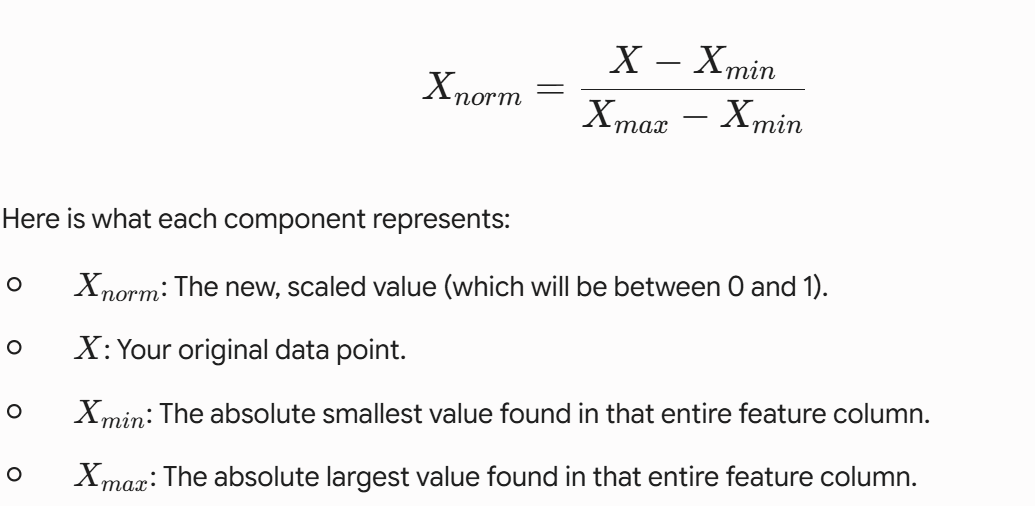

<h4>Absolute Maximum Scaling</h4>
<p>Absolute Maximum Scaling is a feature scaling method where each value is divided by the maximum absolute value of that feature. This transformation rescales the data so that values fall within the range of -1 to 1</p>

<ul>
    <li><b>Sensitive to Outliers:</b> extreme values can affect the maximum vlaue and reduce scaling quality</li>
    <li><b>Best for Clean Data:</b> works better when the dataset does not contain strong outliers</li>
</ul>

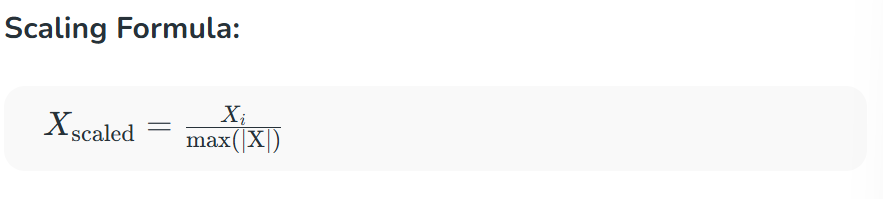

<h4>Robust Scaling</h4>
<p>Robust Scaling scales features using the median and interquartile range (IQR) instead of the mean and standard deviation. This makes it less sensitive to outliers and skewed data, making it suitable for datasets with extreme values or noise</p>


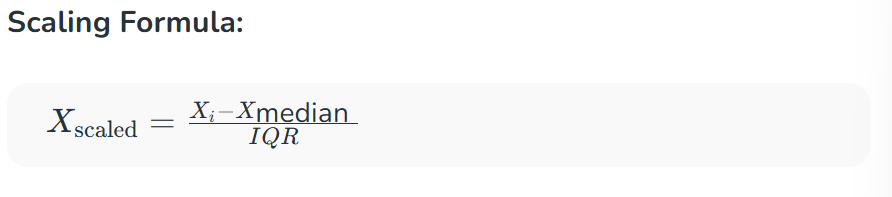

<h2>When to Chooose Normalization vs. Standardization</h2>
<p>The decision almost always comes down to outliers and the specific algorithms you are building</p>

<h5>The outlier weakness</h5>
<p>If your data has extreme outliers, Standardization is usually the safer bet because it centers data around the mean rather than relying on the extreme edges</p>

<h5>When Normalization Wins</h5>
<p>You should explicitly choose Normalization (Min-Max Scaling) in scenarios like these:</p>
<ul>
    <li><b>Strcit Bounded Inputs:</b> certain algorithms, like specific types of Artificial Neural Networks, mathematically require or perform best when inputs are strictly bounded beween 0 and 1</li>
    <li><b>Image Processing:</b> Computer vision models rely on pixel intensities that naturally have hard limits (0 to 255). Dividing by 255 to normalize the data to a 0-1 scale is standard industry practice</li>
    <li><b>Known Boundaries:</b> If you are dealing with data that has natural, physical limits (like a test score that can only range from 0 to 100), Normalization perfectly preserves that relative scale</li>
</ul>

<h5>When Standardization Wins</h5>
<ul>
    <li><b>Computing Distance:</b> Algorithms like KNN, SVM, and K-Means Clustering rely heavily on the physical distance between data points</li>
    <li><b>Using Gradient Descent:</b> Algorithms like Linear Regression, Logistic Regression, and Neural Networks take mathematical steps toward a solution. Standardization helps them take a much faster, more stable path to the right answer</li>
</ul>

<h3>Normalization (Min-Max Scaling) From Scratch</h3>

In [9]:
class CustomMinMaxScaling:
    def __init__(self):
        # these attributes will "memorize" the boundaries of our training data
        self.min_vals = None
        self.max_vals = None

    def fit(self, X):
        """
        Step 1: Calculate and store the min and max for each feature.
        axis=0 ensures we are looking down each column individually.
        """

        self.min_vals = np.min(X, axis = 0)
        self.max_vals = np.max(X, axis = 0)

        # adding this allows for method chaining!
        return self

    def transform(self, X):
        """
        Step 2: Apply the normalization formula to the dataset.
        We add a tiny number (1e-8) to the denominator to prevent division by zero
        just in case all numbers in a column are exactly the same.
        """
        # The Min-Max Formula: (X - X_min) / (X_max - X_min)
        numerator = X - self.min_vals
        denominator = self.max_vals - self.min_vals + 1e-8

        return numerator / denominator

    def fit_transform(self, X):
        """
        A convenience method to calculate the bounds and scale the data in one step.
        """
        self.fit(X)
        return self.transform(X)
        

In [10]:
# 1. Create our raw dataset (Rows represent people, columns represent features)
raw_salaries = np.array([
    [20000],
    [50000],
    [100000]
])
# 2. Instantiate our new scaling tool 
scaler = CustomMinMaxScaling()

# 3. Fit the tool to our data and transform it
normalized_salaries = scaler.fit_transform(raw_salaries)


print("Original Salaries:\n", raw_salaries)
print("\nNormalized Salaries:\n", normalized_salaries)

Original Salaries:
 [[ 20000]
 [ 50000]
 [100000]]

Normalized Salaries:
 [[0.   ]
 [0.375]
 [1.   ]]


<h3>Normalization (Min-Max Scaling) Using Scikit-learn</h3>

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized_sal = scaler.fit_transform(raw_salaries)

print("Scikit-Learn Normalized Salaries:\n", normalized_sal)

Scikit-Learn Normalized Salaries:
 [[0.   ]
 [0.375]
 [1.   ]]


<h3>Applying to a real dataset</h3>

In [19]:
X_normal = df[['Age','EstimatedSalary']].values

class CustomNormalization:
    def __init__(self):
        self.min_val = None
        self.max_val = None

    def fit(self, X):
        self.min_val = np.min(X, axis = 0)
        self.max_val = np.max(X, axis = 0)

        return self

    def transform(self, X):
        numerator = X - self.min_val
        denominator = self.max_val - self.min_val + 1e-8

        return numerator / denominator

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


scaler = CustomNormalization()

normalized_scale = scaler.fit_transform(X_normal)
scaled_df = pd.DataFrame(normalized_scale, columns = ['Scaled Age', 'Scaled Salary'])
# scaled_df.describe()
scaled_df.head()

,Scaled Age,Scaled Salary
0,0.023810,0.029630
1,0.404762,0.037037
2,0.190476,0.207407
3,0.214286,0.311111
4,0.023810,0.451852


In [22]:
X = df[['Age', 'EstimatedSalary']]
scaler = MinMaxScaler().set_output(transform = 'pandas')
X_scaled = scaler.fit_transform(X)
X_scaled.head()

,Age,EstimatedSalary
0,0.023810,0.029630
1,0.404762,0.037037
2,0.190476,0.207407
3,0.214286,0.311111
4,0.023810,0.451852


<h3>Applying to a model</h3>

In [24]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [26]:
X = df[['Age','EstimatedSalary']]
y = df['Purchased']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state= 42)


scaler = MinMaxScaler().set_output(transform = 'pandas')
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled,y_train)
y_predict = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_predict)

print(f"Accuracy (Normalized Data): {accuracy * 100:.2f}%")

Accuracy (Normalized Data): 93.00%
